In [1]:
! pip install pyowm

In [2]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_community.utilities import OpenWeatherMapAPIWrapper
from dotenv import load_dotenv
load_dotenv()

@tool
def check_weather_safety(destination: str) -> str:
    """Checks weather. Returns 'Safe' or 'Warning' with details."""
    weather = OpenWeatherMapAPIWrapper(openweathermap_api_key=os.getenv("OPENWEATHERMAP_API_KEY"))
    data = weather.run(destination)
    # Logic: If 'rain' in data, suggest indoor activities
    return f"Weather in {destination}: {data}. Advice: Proceed with the trip but carry an umbrella."


@tool
def calculate_final_costs(transport: float, hotel_daily: float, days: int, food_daily: float) -> dict:
    """Calculates total trip cost. Essential for Point 7."""
    total_stay = (hotel_daily + food_daily) * days
    grand_total = total_stay + transport
    return {
        "total_stay_cost": total_stay,
        "grand_total": grand_total,
        "currency": "BDT"
    }



tavily_key = os.getenv("TAVILY_API_KEY")
search_tool = TavilySearchResults(k=3, api_key=tavily_key)

# Option B: Manual Wrapper (If Option A fails)
# wrapper = TavilySearchAPIWrapper(tavily_api_key=os.getenv("TAVILY_API_KEY"))
# search_tool = TavilySearchResults(api_wrapper=wrapper, k=3)

# tools = [search_tool, check_weather_safety]
tools = [search_tool]

/tmp/ipykernel_6713/2851004855.py:31: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(k=3, api_key=tavily_key)


In [3]:
import os

from langchain.agents import create_agent
from tools import tools
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

from pydantic import BaseModel, Field
from typing import List

load_dotenv()

class DayItinerary(BaseModel):
    day_number: int = Field(description="The sequential day number of the trip")
    Time_of_day: str = Field(description="Specific period: Morning, Afternoon, or Evening")
    activity_timing: str = Field(description="Point 6: Breakdown of time spent in area and local enjoyment")
    tourist_attraction: str = Field(description="Point 2: The primary specific tourist attraction to visit")
    spots: List[str] = Field(description="Point 5: Top 5 specific spots/locations to visit for this day")
    local_food_suggestions: List[str] = Field(description="Point 4: Specific local food items to try")
    restaurant_suggestions: List[str] = Field(description="Point 5: Specific restaurant names to visit")
    Hotel_suggestion: str = Field(description="Point 3: Specific hotel recommendation for the day")
    Hotel_cost: float = Field(description="Point 3 & 7: Estimated cost for the hotel stay in USD/BDT")
    estimated_daily_cost: float = Field(description="Point 7: Total sum of transport, food, and attractions for this day")

class FinalTravelPlan(BaseModel):
    destination: str
    weather_status: str = Field(description="Point 2: Current weather condition and safety advice")
    daily_plans: List[DayItinerary]
    total_estimated_budget: float = Field(description="Point 7: The absolute final solid total cost for the entire trip")


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7,api_key=os.getenv("OPENAI_API_KEY"))



travel_agent = create_agent(
    model=llm,
    tools=tools,
    response_format=FinalTravelPlan,
    system_prompt=(
    "You are a realistic Travel Planner. "
    "IMPORTANT: Daily costs must be realistic and vary day-by-day. "
    "Do not simply divide the total budget by the number of days. "
    "For example, a day with a Safari Park visit should cost more than a day at the beach."

    )
)


/home/ahmed/miniconda3/envs/ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv(override=True)

True

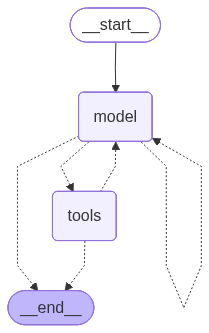

In [5]:
travel_agent

In [6]:
response = travel_agent.invoke({"messages": [("user", "Plan a 5-day trip to Bangladesh in Cox's Bazar with a $300 budget.")]})


In [7]:
response

{'messages': [HumanMessage(content="Plan a 5-day trip to Bangladesh in Cox's Bazar with a $300 budget.", additional_kwargs={}, response_metadata={}, id='f5799978-5873-4a6a-adbe-e31ab665a24f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 436, 'total_tokens': 456, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6a22de2fb7', 'id': 'chatcmpl-DH3S5ekvWaU0p00ceRv8w68FAjHCe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ccc7c-2cde-79b0-8ad6-15e1a7e9a72b-0', tool_calls=[{'name': 'check_weather_safety', 'args': {'destination': "Cox's Bazar"}, 'id': 'call_Z4R6WdoFZAKDZIaEfO9Y54tn', 'type': 'tool_call'}], inval

In [ ]:
# from agent import travel_agent


response = travel_agent.invoke({"messages": [("user", "Plan a 5-day trip to Bangladesh in Cox's Bazar with a $300 budget.")]})
print(response.json())

# Assuming 'response' is the output from travel_agent.invoke(...)
plan = response["structured_response"]

print(f"==========================================")
print(f"🗺️ TRIP PLAN TO: {plan.destination.upper()}")
print(f"🌦️ WEATHER STATUS: {plan.weather_status}")
print(f"==========================================\n")

for day in plan.daily_plans:
    print(f"📅 DAY {day.day_number}: {day.Time_of_day}")
    print(f"------------------------------------------")
    print(f"📍 MAIN ATTRACTION: {day.tourist_attraction}")
    print(f"🏨 HOTEL: {day.Hotel_suggestion} (Cost: ${day.Hotel_cost})")
    print(f"✨ TOP SPOTS: {', '.join(day.spots)}")
    print(f"🍱 LOCAL FOOD: {', '.join(day.local_food_suggestions)}")
    print(f"🍽️ RESTAURANT: {', '.join(day.restaurant_suggestions)}")
    print(f"🕒 SCHEDULE: {day.activity_timing}")
    print(f"💰 ESTIMATED DAILY COST: ${day.estimated_daily_cost}")
    print(f"------------------------------------------\n")

print(f"✅ TOTAL SOLID BUDGET: ${plan.total_estimated_budget}")

🗺️ TRIP PLAN TO: COX'S BAZAR
🌦️ WEATHER STATUS: Safe - clear sky. Carry an umbrella.

📅 DAY 1: Morning
------------------------------------------
📍 MAIN ATTRACTION: Cox's Bazar Beach
🏨 HOTEL: Hotel Sea View (Cost: $40.0)
✨ TOP SPOTS: Cox's Bazar Beach, Laboni Beach, Himchari National Park, Inani Beach, Marine Drive
🍱 LOCAL FOOD: Seafood Platter, Panta Bhat, Hilsa Fish Curry
🍽️ RESTAURANT: Sea Pearl Restaurant, Handi Restaurant
🕒 SCHEDULE: 4 hours
💰 ESTIMATED DAILY COST: $50.0
------------------------------------------

📅 DAY 2: Afternoon
------------------------------------------
📍 MAIN ATTRACTION: Himchari National Park
🏨 HOTEL: Hotel Sea View (Cost: $40.0)
✨ TOP SPOTS: Himchari Waterfall, Himchari Beach, Cox's Bazar Sea Park, Kolatoli Beach, Sadarghat
🍱 LOCAL FOOD: Chicken Bhuna, Fried Prawns, Samosa
🍽️ RESTAURANT: Maya Restaurant, Mermaid Restaurant
🕒 SCHEDULE: 5 hours
💰 ESTIMATED DAILY COST: $70.0
------------------------------------------

📅 DAY 3: Evening
------------------------

In [9]:
response = travel_agent.invoke({"messages": [("user", "Plan a 5-day trip to Bangladesh to Switzerland with a $300 budget.")]})


In [10]:
# Assuming 'response' is the output from travel_agent.invoke(...)
plan = response["structured_response"]

print(f"==========================================")
print(f"🗺️ TRIP PLAN TO: {plan.destination.upper()}")
print(f"🌦️ WEATHER STATUS: {plan.weather_status}")
print(f"==========================================\n")

for day in plan.daily_plans:
    print(f"📅 DAY {day.day_number}: {day.Time_of_day}")
    print(f"------------------------------------------")
    print(f"📍 MAIN ATTRACTION: {day.tourist_attraction}")
    print(f"🏨 HOTEL: {day.Hotel_suggestion} (Cost: ${day.Hotel_cost})")
    print(f"✨ TOP SPOTS: {', '.join(day.spots)}")
    print(f"🍱 LOCAL FOOD: {', '.join(day.local_food_suggestions)}")
    print(f"🍽️ RESTAURANT: {', '.join(day.restaurant_suggestions)}")
    print(f"🕒 SCHEDULE: {day.activity_timing}")
    print(f"💰 ESTIMATED DAILY COST: ${day.estimated_daily_cost}")
    print(f"------------------------------------------\n")

print(f"✅ TOTAL SOLID BUDGET: ${plan.total_estimated_budget}")

🗺️ TRIP PLAN TO: SWITZERLAND
🌦️ WEATHER STATUS: Safe: Overcast clouds, carry an umbrella.

📅 DAY 1: Morning
------------------------------------------
📍 MAIN ATTRACTION: Lake Geneva
🏨 HOTEL: Budget Hotel in Lausanne (Cost: $50.0)
✨ TOP SPOTS: Jet d'Eau, Montreux, Chillon Castle, Lausanne, Vevey
🍱 LOCAL FOOD: Rösti, Fondue
🍽️ RESTAURANT: Restaurant de l'Hôtel de Ville, Café du Grütli
🕒 SCHEDULE: 4 hours
💰 ESTIMATED DAILY COST: $80.0
------------------------------------------

📅 DAY 2: Morning
------------------------------------------
📍 MAIN ATTRACTION: Zurich Old Town
🏨 HOTEL: Hostel in Zurich (Cost: $45.0)
✨ TOP SPOTS: Bahnhofstrasse, Grossmünster, Fraumünster, Niederdorf, Swiss National Museum
🍱 LOCAL FOOD: Spätzle, Zürcher Geschnetzeltes
🍽️ RESTAURANT: Zeughauskeller, Restaurant Swiss Chuchi
🕒 SCHEDULE: 4 hours
💰 ESTIMATED DAILY COST: $75.0
------------------------------------------

📅 DAY 3: All Day
------------------------------------------
📍 MAIN ATTRACTION: Jungfraujoch
🏨 HOTEL: